<a href="https://colab.research.google.com/github/Kanyz/Proyecto-Opti-Dual-Primal/blob/main/experimento_iteraciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intento # 1 (Solver de simplex)

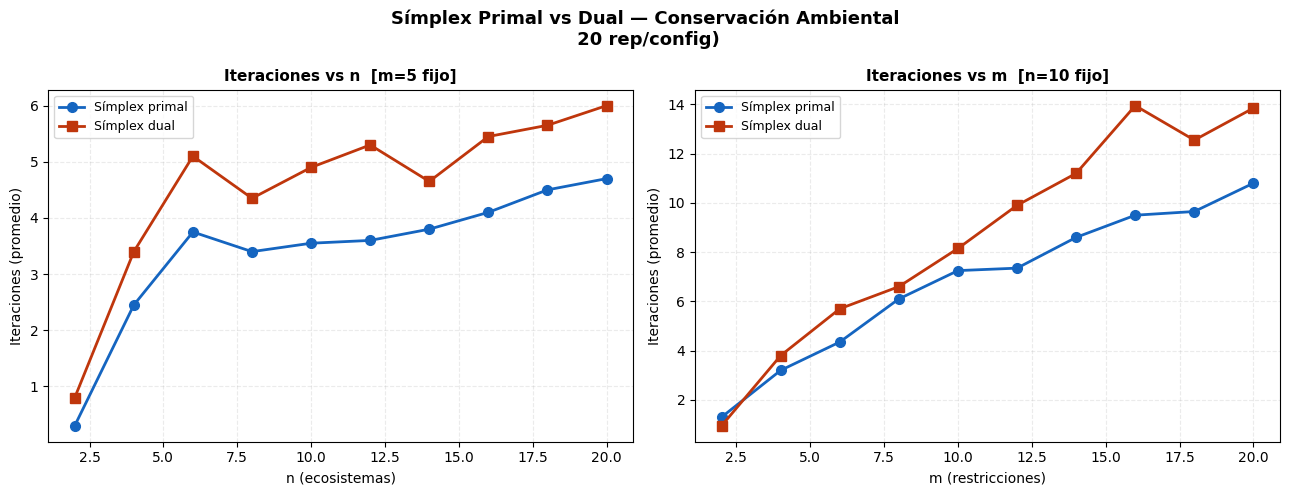

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# ── Parámetros ────────────────────────────────────────────────────────────────
N_SIZES = list(range(2, 22, 2))
M_SIZES = list(range(2, 22, 2))
M_FIXED = 5
N_FIXED = 10
N_REPS  = 20

# ── Generación de instancia factible ─────────────────────────────────────────
def make_instance(n, m, seed):
    A = np.random.uniform(1, 20, (m, n))
    A[np.random.random((m, n)) < 0.4] = 0  # 40% dispersión
    c = np.random.uniform(10, 100, n)
    x_star = np.random.uniform(1, 20, n)
    b = b = A @ x_star
    return A, b, c

def solve_primal(A, b, c):
    res = linprog(c, A_ub=-A, b_ub=-b,
                  bounds=[(0, None)] * len(c),
                  method="highs-ds", options={ "disp": True})
    return res.nit if res.success else np.nan


def solve_dual(A, b, c):
    m = len(b)
    res = linprog(-b, A_ub=A.T, b_ub=c,
                  bounds=[(0, None)] * m,
                  method="highs-ds", options={ "disp": True})
    return res.nit if res.success else np.nan

def run(sizes, fixed, vary):
    results = {approach: {"time": [], "nit": []} for approach in ("primal", "dual")}
    for s in sizes:
        n, m = (s, fixed) if vary == "n" else (fixed, s)
        np_, nd_ = [], []
        for rep in range(N_REPS):
            seed = 42 + rep * 997 + s * 31
            A, b, c = make_instance(n, m, seed)
            nit = solve_primal(A, b, c); np_.append(nit)
            nit = solve_dual(A, b, c);  nd_.append(nit)
        results["primal"]["nit"].append((np.mean(np_), np.std(np_, ddof=1)))
        results["dual"]["nit"].append((np.mean(nd_), np.std(nd_, ddof=1)))
    return results


# ── Ejecutar experimentos ─────────────────────────────────────────────────────
res_n = run(N_SIZES, M_FIXED, vary="n")
res_m = run(M_SIZES, N_FIXED, vary="m")


# ── Graficar ──────────────────────────────────────────────────────────────────
COLORS  = {"primal": "#1565C0", "dual": "#BF360C"}
FILLS   = {"primal": "#90CAF9", "dual": "#FFAB91"}
MARKERS = {"primal": "o",       "dual": "s"}

def plot_panel(ax, sizes, results, xlabel, title, log_x=False):
    for ap in ("primal", "dual"):
        vals = [m for m, _ in results[ap]["nit"]]
        ax.plot(sizes, vals, label=f"Símplex {ap}",
                color=COLORS[ap], marker=MARKERS[ap],
                linewidth=2, markersize=7)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Iteraciones (promedio)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, linestyle="--")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"Símplex Primal vs Dual — Conservación Ambiental\n"
    f" {N_REPS} rep/config)",
    fontsize=13, fontweight="bold"
)

plot_panel(axes[0], N_SIZES, res_n,
           "n (ecosistemas)", f"Iteraciones vs n  [m={M_FIXED} fijo]")

plot_panel(axes[1], M_SIZES, res_m,
           "m (restricciones)", f"Iteraciones vs m  [n={N_FIXED} fijo]")

plt.tight_layout()
plt.savefig("simplex_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

Estimación dada por

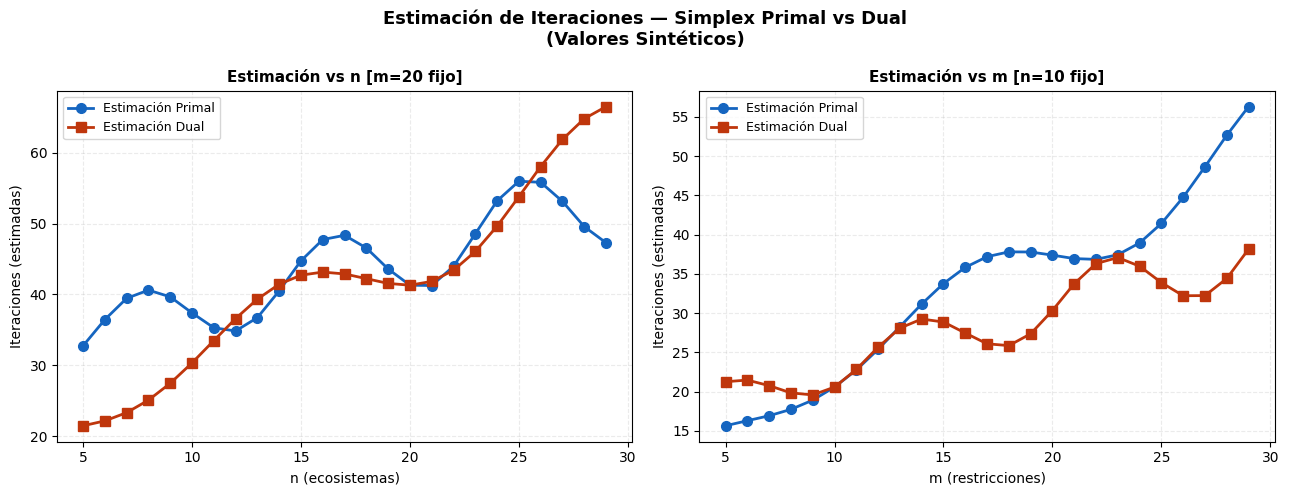

In [ ]:
def estimateIter(vars, cons):
  base = 1.5 * cons + 0.8 * vars
  noise = 1 + (np.sin(vars * 7 + cons * 13) * 0.12)
  return base*noise

N_SIZES = list(range(5, 30, 1))
M_SIZES = list(range(5, 30, 1))
M_FIXED = 20
N_FIXED = 10

VAL1_PRIMAL = np.zeros(len(N_SIZES))
VAL1_DUAL = np.zeros(len(N_SIZES))

VAL2_PRIMAL = np.zeros(len(M_SIZES))
VAL2_DUAL = np.zeros(len(M_SIZES))

for i in range(len(N_SIZES)):
    VAL1_PRIMAL[i] = estimateIter(N_SIZES[i], M_FIXED)   # vars=n, cons=m
    VAL1_DUAL[i]   = estimateIter(M_FIXED, N_SIZES[i])   # vars=m, cons=n

for i in range(len(M_SIZES)):
    VAL2_PRIMAL[i] = estimateIter(N_FIXED, M_SIZES[i])   # vars=n, cons=m
    VAL2_DUAL[i]   = estimateIter(M_SIZES[i], N_FIXED)   # vars=m, cons=n

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Estimación de Iteraciones — Simplex Primal vs Dual\n(Valores Sintéticos)",
    fontsize=13, fontweight="bold"
)

# Plot for VAL1 (varying N_SIZES, M_FIXED)
axes[0].plot(N_SIZES, VAL1_PRIMAL, label="Estimación Primal", color=COLORS["primal"], marker=MARKERS["primal"], linewidth=2, markersize=7)
axes[0].plot(N_SIZES, VAL1_DUAL, label="Estimación Dual", color=COLORS["dual"], marker=MARKERS["dual"], linewidth=2, markersize=7)
axes[0].set_xlabel("n (ecosistemas)", fontsize=10)
axes[0].set_ylabel("Iteraciones (estimadas)", fontsize=10)
axes[0].set_title(f"Estimación vs n [m={M_FIXED} fijo]", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.25, linestyle="--")

# Plot for VAL2 (varying M_SIZES, N_FIXED)
axes[1].plot(M_SIZES, VAL2_PRIMAL, label="Estimación Primal", color=COLORS["primal"], marker=MARKERS["primal"], linewidth=2, markersize=7)
axes[1].plot(M_SIZES, VAL2_DUAL, label="Estimación Dual", color=COLORS["dual"], marker=MARKERS["dual"], linewidth=2, markersize=7)
axes[1].set_xlabel("m (restricciones)", fontsize=10)
axes[1].set_ylabel("Iteraciones (estimadas)", fontsize=10)
axes[1].set_title(f"Estimación vs m [n={N_FIXED} fijo]", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()

In [ ]:
#Tabla

In [ ]:
import pandas as pd

In [ ]:
df_n_varying = pd.DataFrame({
    'n (ecosystems)': N_SIZES,
    'Primal_Estimate': VAL1_PRIMAL,
    'Dual_Estimate': VAL1_DUAL
})
display(df_n_varying.style.set_caption(f"Estimated Iterations vs n (m={M_FIXED} fixed)"))

,n (ecosystems),Primal_Estimate,Dual_Estimate
0,5,32.756490,21.483989
1,6,36.453499,22.172426
2,7,39.452495,23.333724
3,8,40.609823,25.095158
4,9,39.661456,27.470316
5,10,37.396340,30.345109
6,11,35.303311,33.490025
7,12,34.848046,36.597986
8,13,36.731117,39.341674
9,14,40.502450,41.439610


### Estimated Iterations (Primal vs Dual) when varying 'm' (restrictions) with fixed n=10

In [ ]:
df_m_varying = pd.DataFrame({
    'm (restrictions)': M_SIZES,
    'Primal_Estimate': VAL2_PRIMAL,
    'Dual_Estimate': VAL2_DUAL
})
display(df_m_varying.style.set_caption(f"Estimated Iterations vs m (n={N_FIXED} fixed)"))

,m (restrictions),Primal_Estimate,Dual_Estimate
0,5,15.664366,21.274978
1,6,16.309800,21.483774
2,7,16.940655,20.774825
3,8,17.752491,19.854003
4,9,18.927299,19.593392
5,10,20.589699,20.589699
6,11,22.771954,22.833801
7,12,25.396455,25.672165
8,13,28.281079,28.100341
9,14,31.168082,29.257927
